In [17]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.src.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import seaborn as sns

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# Data paths and parameters
train_dir = '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset_clean'
img_size = (224, 224)
batch_size = 32
project_root = Path('/home/groggy/projects/Image-Classification-Explainability')

In [19]:
train_datagen = ImageDataGenerator(
    # rescale=1./255, debt from previous model
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,  # Don't shuffle for analysis
    seed=SEED
)

num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Found 7200 images belonging to 9 classes.
Found 1800 images belonging to 9 classes.
Number of classes: 9
Class names: ['Black Sea Sprat', 'Gilt-Head Bream', 'Hourse Mackerel', 'Red Mullet', 'Red Sea Bream', 'Sea Bass', 'Shrimp', 'Striped Red Mullet', 'Trout']
Training samples: 7200
Validation samples: 1800


## Architecture Testing Zone

**Baseline (from previous notebook):**
- GlobalAveragePooling2D → Dense(9, softmax)
- Trainable params: ~4,617
- Best val_accuracy: 0.2589 (25.89%)


In [5]:
# Build base model
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Keep frozen for now

print(f"Base model output shape: {base_model.output_shape}")
print(f"Base model has {len(base_model.layers)} layers")

I0000 00:00:1777505679.976808 1488255 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5562 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6


Base model output shape: (None, 7, 7, 960)
Base model has 187 layers


In [6]:
# EXPERIMENT: Build classifier head
# Modify this architecture to test different configurations

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu', name='dense_512')(x)
x = Dropout(0.5, name='dropout_1')(x)
x = Dense(256, activation='relu', name='dense_256')(x)
x = Dropout(0.3, name='dropout_2')(x)
predictions = Dense(num_classes, activation='softmax', name='predictions')(x)

# Option 3: Add your own architecture here!
# x = Dense(???, activation='relu')(x)
# ...

model = Model(inputs=base_model.input, outputs=predictions)

print(f"\\nTotal parameters: {model.count_params():,}")
print(f"Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"Non-trainable parameters: {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")

\nTotal parameters: 3,622,025
Trainable parameters: 625,673
Non-trainable parameters: 2,996,352


In [7]:
# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Create ModelCheckpoint callback to save best model based on val_loss
checkpoint_path = project_root / 'ML' / 'Models' / 'MobileNetV3Large_Improved_best.keras'
checkpoint = ModelCheckpoint(
    filepath=str(checkpoint_path),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint]
)

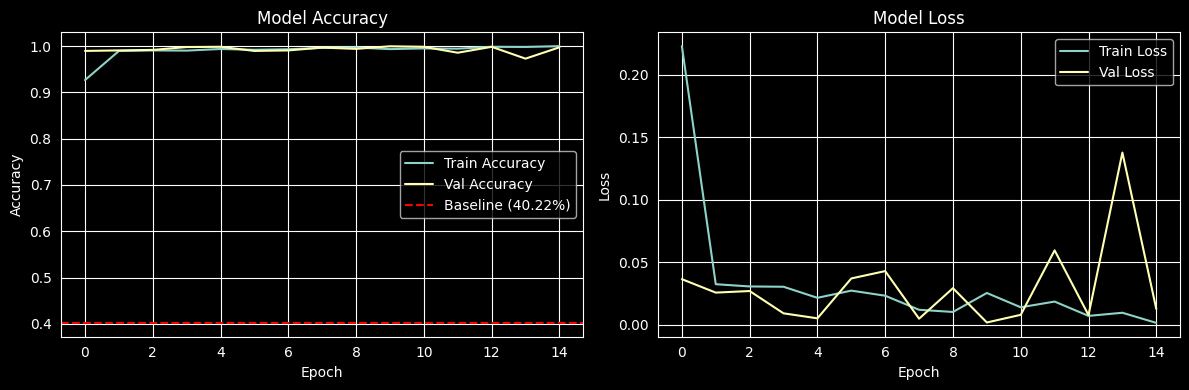

In [29]:
# Visualize training results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.axhline(y=0.4022, color='r', linestyle='--', label='Baseline (40.22%)')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Results summary
best_val_acc = max(history.history['val_accuracy'])
final_val_acc = history.history['val_accuracy'][-1]
baseline_acc = 0.2589

print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Baseline validation accuracy:     {baseline_acc:.4f} (25.89%)")
print(f"Current best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Final validation accuracy:        {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"Improvement over baseline:        {(best_val_acc - baseline_acc):.4f} ({(best_val_acc - baseline_acc)*100:.2f}%)")
print("=" * 60)

if best_val_acc > baseline_acc:
    print("✓ Architecture improved performance!")
else:
    print("✗ No improvement - try different architecture")

RESULTS SUMMARY
Baseline validation accuracy:     0.2589 (25.89%)
Current best validation accuracy: 0.9994 (99.94%)
Final validation accuracy:        0.9972 (99.72%)
Improvement over baseline:        0.7405 (74.05%)
✓ Architecture improved performance!


In [11]:
# Save model if improved
if best_val_acc > baseline_acc:
    save_path = project_root / 'ML' / 'Models' / 'MobileNetV3Large_Improved.keras'
    model.save(save_path)
    print(f'✓ Model saved to: {save_path}')
else:
    print('Model not saved (no improvement over baseline)')

✓ Model saved to: /home/groggy/projects/Image-Classification-Explainability/ML/Models/MobileNetV3Large_Improved.keras


In [ ]:
model.summary()

# deeper analysis

In [21]:
# Evaluate model on validation set
print("Evaluating model on validation set...")
val_loss, val_accuracy = model.evaluate(val_generator, verbose=1)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

# Generate predictions
print("\nGenerating predictions...")
val_generator.reset()  # Reset to start
predictions = model.predict(val_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes

print(f"\nPredictions shape: {predictions.shape}")
print(f"Number of predictions: {len(predicted_classes)}")
print(f"Number of true labels: {len(true_classes)}")

Evaluating model on validation set...
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 241ms/step - accuracy: 0.9972 - loss: 0.0125

Validation Loss: 0.0125
Validation Accuracy: 0.9972 (99.72%)

Generating predictions...
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 217ms/step

Predictions shape: (1800, 9)
Number of predictions: 1800
Number of true labels: 1800


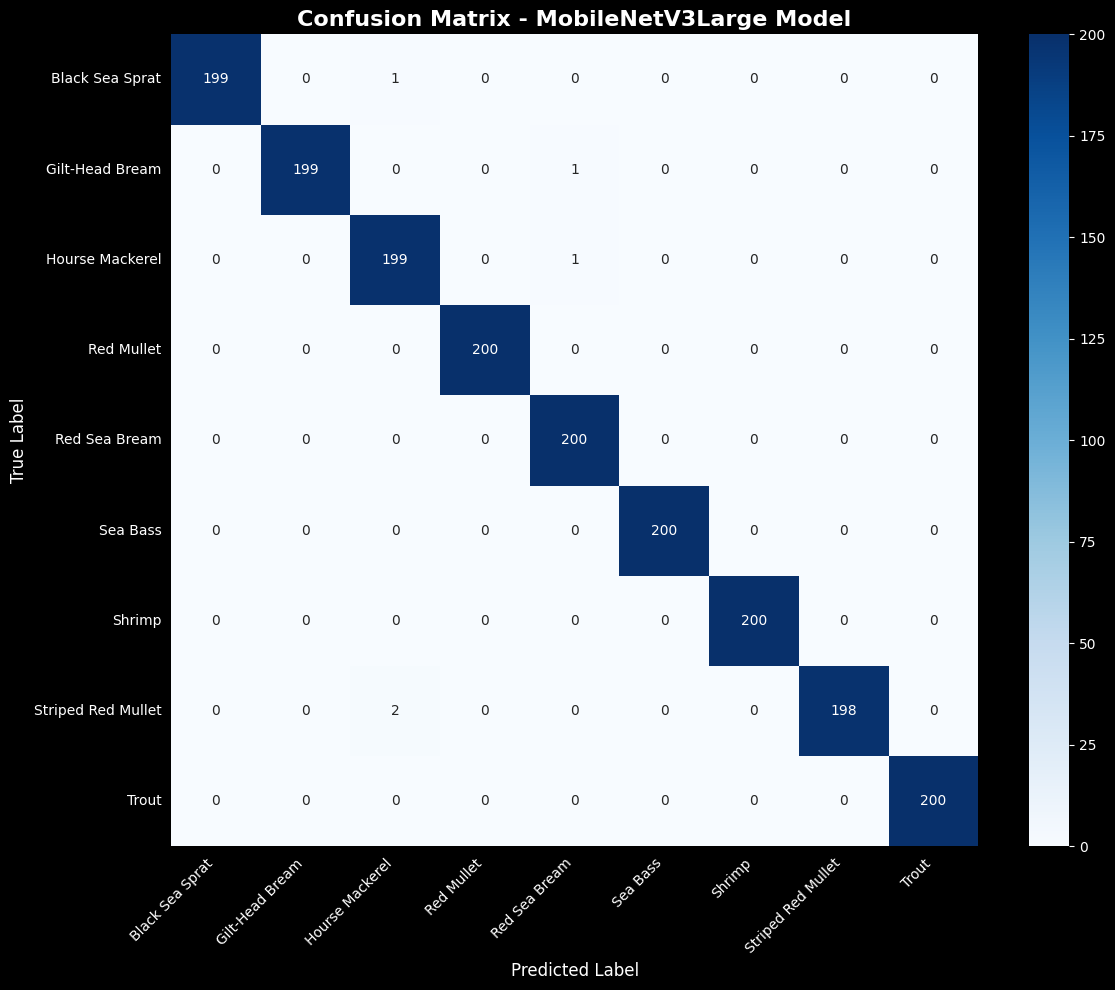

In [22]:
# Chart 1: Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - MobileNetV3Large Model', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

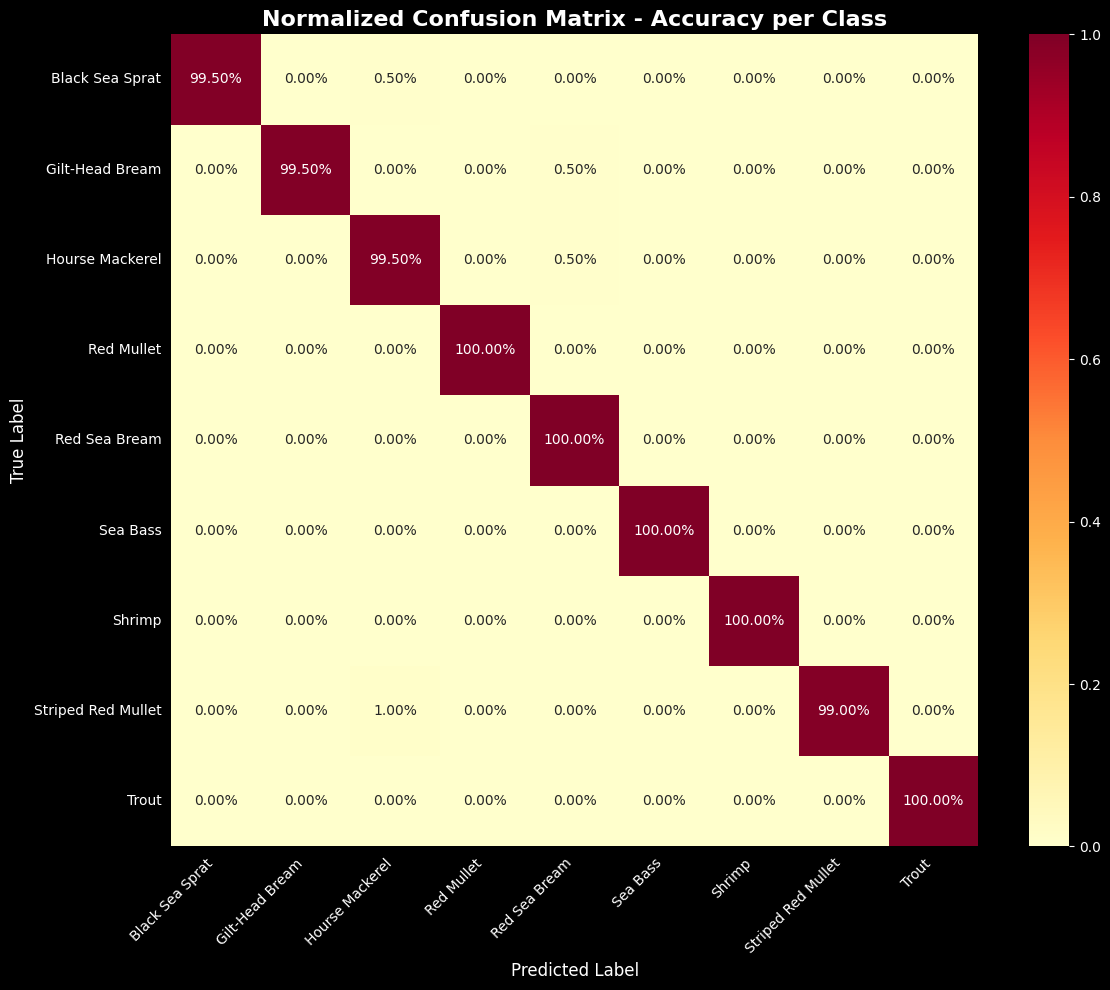

In [23]:
# Chart 2: Normalized Confusion Matrix (Accuracy per class)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix - Accuracy per Class', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

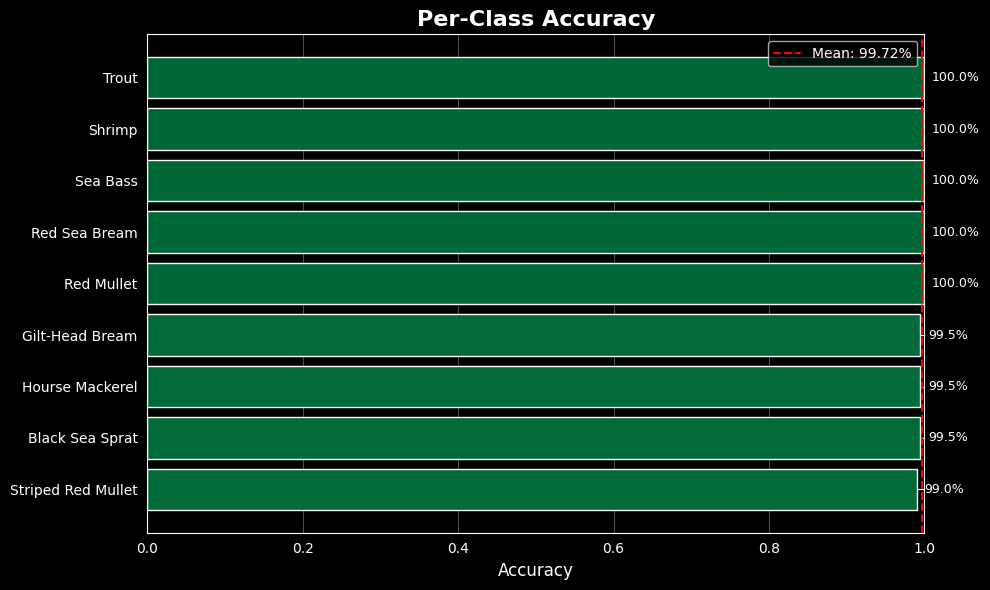


Class Accuracy Summary:
             Class  Accuracy
        Red Mullet     1.000
             Trout     1.000
            Shrimp     1.000
          Sea Bass     1.000
     Red Sea Bream     1.000
   Black Sea Sprat     0.995
   Gilt-Head Bream     0.995
   Hourse Mackerel     0.995
Striped Red Mullet     0.990


In [24]:
# Chart 3: Per-Class Accuracy Bar Chart
class_accuracies = cm_normalized.diagonal()
class_acc_df = pd.DataFrame({
    'Class': class_names,
    'Accuracy': class_accuracies
}).sort_values('Accuracy', ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(class_acc_df['Accuracy'])
bars = plt.barh(class_acc_df['Class'], class_acc_df['Accuracy'], color=colors)
plt.xlabel('Accuracy', fontsize=12)
plt.title('Per-Class Accuracy', fontsize=16, fontweight='bold')
plt.xlim(0, 1)
plt.axvline(x=class_acc_df['Accuracy'].mean(), color='red', linestyle='--',
            label=f'Mean: {class_acc_df["Accuracy"].mean():.2%}')
plt.legend()
plt.grid(axis='x', alpha=0.3)

# Add percentage labels
for i, (idx, row) in enumerate(class_acc_df.iterrows()):
    plt.text(row['Accuracy'] + 0.01, i, f"{row['Accuracy']:.1%}",
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nClass Accuracy Summary:")
print(class_acc_df.sort_values('Accuracy', ascending=False).to_string(index=False))

/tmp/ipykernel_1488255/1603823016.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([max_confidences[correct_predictions], max_confidences[~correct_predictions]],


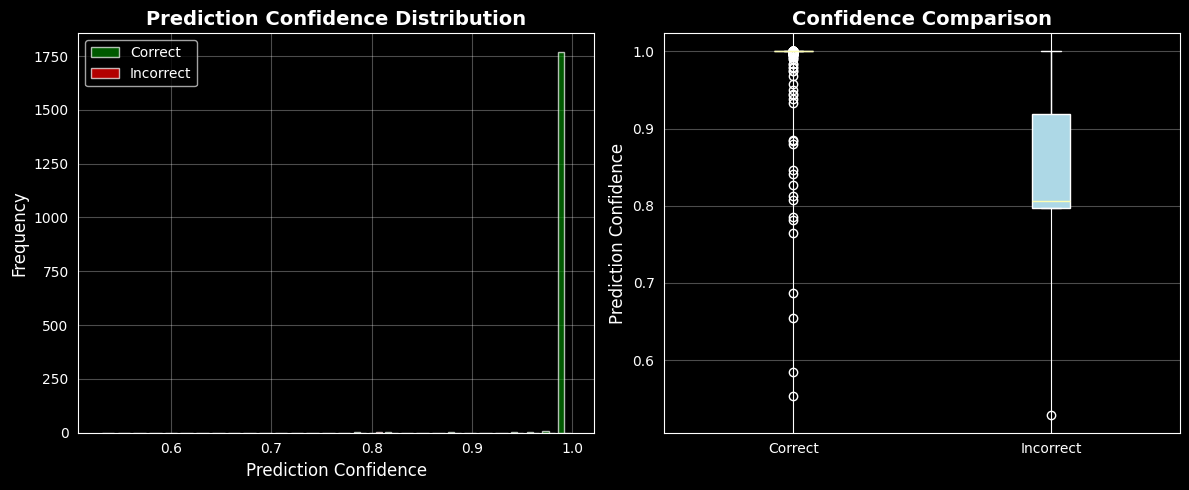


Mean confidence (correct): 0.9978
Mean confidence (incorrect): 0.8102


In [25]:
# Chart 4: Prediction Confidence Distribution
max_confidences = np.max(predictions, axis=1)
correct_predictions = (predicted_classes == true_classes)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist([max_confidences[correct_predictions], max_confidences[~correct_predictions]], 
         bins=30, label=['Correct', 'Incorrect'], alpha=0.7, color=['green', 'red'])
plt.xlabel('Prediction Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([max_confidences[correct_predictions], max_confidences[~correct_predictions]], 
            labels=['Correct', 'Incorrect'], patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.ylabel('Prediction Confidence', fontsize=12)
plt.title('Confidence Comparison', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMean confidence (correct): {max_confidences[correct_predictions].mean():.4f}")
if np.sum(~correct_predictions) > 0:
    print(f"Mean confidence (incorrect): {max_confidences[~correct_predictions].mean():.4f}")
else:
    print("Mean confidence (incorrect): N/A (no incorrect predictions!)")

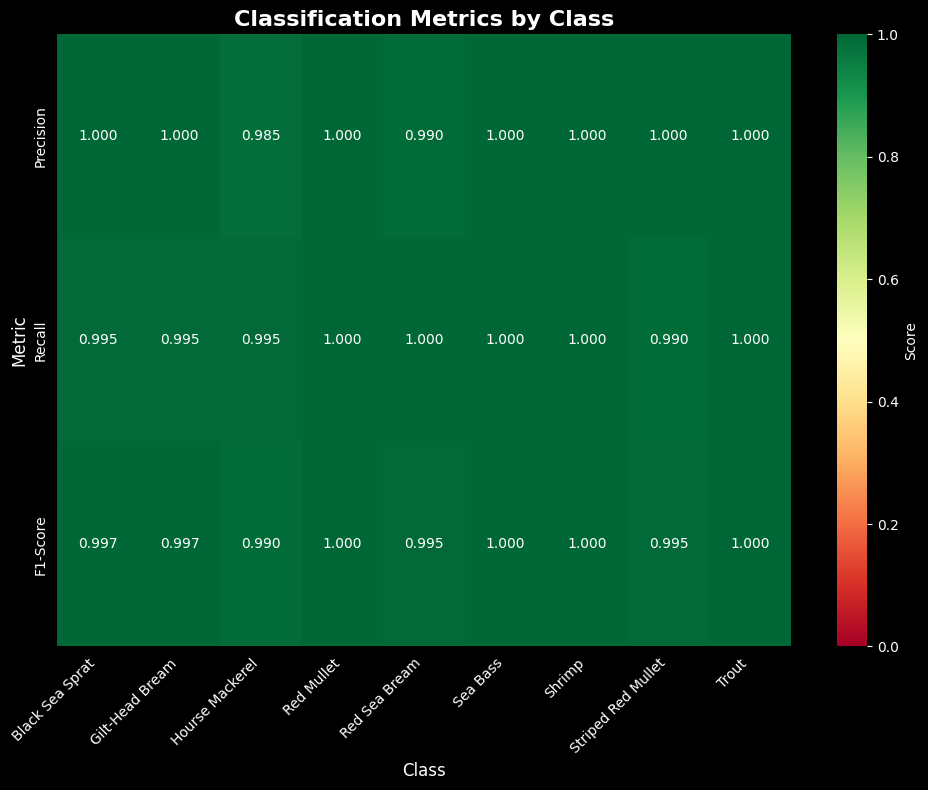


Detailed Classification Report:
                    precision    recall  f1-score   support

   Black Sea Sprat       1.00      0.99      1.00       200
   Gilt-Head Bream       1.00      0.99      1.00       200
   Hourse Mackerel       0.99      0.99      0.99       200
        Red Mullet       1.00      1.00      1.00       200
     Red Sea Bream       0.99      1.00      1.00       200
          Sea Bass       1.00      1.00      1.00       200
            Shrimp       1.00      1.00      1.00       200
Striped Red Mullet       1.00      0.99      0.99       200
             Trout       1.00      1.00      1.00       200

          accuracy                           1.00      1800
         macro avg       1.00      1.00      1.00      1800
      weighted avg       1.00      1.00      1.00      1800



In [26]:
# Chart 5: Classification Report Heatmap
from sklearn.metrics import classification_report, precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    true_classes, predicted_classes, labels=range(len(class_names))
)

metrics_df = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}, index=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(metrics_df.T, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Score'})
plt.title('Classification Metrics by Class', fontsize=16, fontweight='bold')
plt.ylabel('Metric', fontsize=12)
plt.xlabel('Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

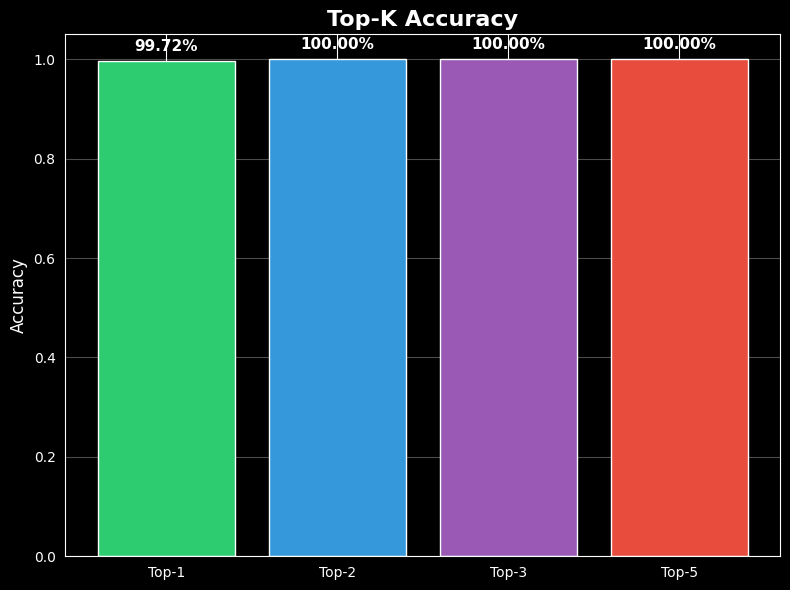


Top-K Accuracy:
  Top-1: 0.9972 (99.72%)
  Top-2: 1.0000 (100.00%)
  Top-3: 1.0000 (100.00%)
  Top-5: 1.0000 (100.00%)


In [27]:
# Chart 6: Top-K Accuracy Analysis
top_k_accuracies = {}
for k in [1, 2, 3, 5]:
    top_k_pred = np.argsort(predictions, axis=1)[:, -k:]
    top_k_correct = np.sum([true_classes[i] in top_k_pred[i] for i in range(len(true_classes))])
    top_k_accuracies[f'Top-{k}'] = top_k_correct / len(true_classes)

plt.figure(figsize=(8, 6))
bars = plt.bar(top_k_accuracies.keys(), top_k_accuracies.values(), 
               color=['#2ecc71', '#3498db', '#9b59b6', '#e74c3c'])
plt.ylabel('Accuracy', fontsize=12)
plt.title('Top-K Accuracy', fontsize=16, fontweight='bold')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)

for i, (k, v) in enumerate(top_k_accuracies.items()):
    plt.text(i, v + 0.02, f'{v:.2%}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTop-K Accuracy:")
for k, acc in top_k_accuracies.items():
    print(f"  {k}: {acc:.4f} ({acc:.2%})")

In [28]:
# Final Summary Statistics
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print("\n" + "="*70)
print("FINAL MODEL ANALYSIS SUMMARY")
print("="*70)
print(f"\nMODEL ARCHITECTURE:")
print(f"  Total Parameters: {total_params:,}")
print(f"  Trainable Parameters: {trainable_params:,}")
print(f"  Non-trainable Parameters: {non_trainable_params:,}")
print(f"\nVALIDATION PERFORMANCE:")
print(f"  Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"  Validation Loss: {val_loss:.4f}")
print(f"\nCLASS PERFORMANCE:")
print(f"  Number of Classes: {len(class_names)}")
print(f"  Best Performing Class: {class_acc_df.iloc[-1]['Class']} ({class_acc_df.iloc[-1]['Accuracy']:.2%})")
print(f"  Worst Performing Class: {class_acc_df.iloc[0]['Class']} ({class_acc_df.iloc[0]['Accuracy']:.2%})")
print(f"  Mean Class Accuracy: {class_acc_df['Accuracy'].mean():.2%}")
print(f"\nPREDICTION STATISTICS:")
print(f"  Total Validation Samples: {len(true_classes)}")
print(f"  Correct Predictions: {np.sum(correct_predictions)}")
print(f"  Incorrect Predictions: {np.sum(~correct_predictions)}")
print(f"  Overall Accuracy: {np.sum(correct_predictions)/len(true_classes):.2%}")
print("="*70)


FINAL MODEL ANALYSIS SUMMARY

MODEL ARCHITECTURE:
  Total Parameters: 3,622,025
  Trainable Parameters: 625,673
  Non-trainable Parameters: 2,996,352

VALIDATION PERFORMANCE:
  Validation Accuracy: 0.9972 (99.72%)
  Validation Loss: 0.0125

CLASS PERFORMANCE:
  Number of Classes: 9
  Best Performing Class: Trout (100.00%)
  Worst Performing Class: Striped Red Mullet (99.00%)
  Mean Class Accuracy: 99.72%

PREDICTION STATISTICS:
  Total Validation Samples: 1800
  Correct Predictions: 1795
  Incorrect Predictions: 5
  Overall Accuracy: 99.72%
